# **Map SalishSea**

In [2]:
%matplotlib inline
import numpy as np
import xarray as xr
import os
import sys
from matplotlib import pyplot as plt, animation, rc
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from cartopy import crs, feature
from datetime import datetime, timedelta
import cmocean

cmap = cmocean.cm.deep

In [3]:
paths = {'NEMO': '/results2/SalishSea/nowcast-green.202111/',
'coords': '/ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'coordsWW3': '/ocean/jvalenti/MOAD/grid2/WW3_grid.nc',
'mask': '/ocean/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc',
'bat': '/ocean/jvalenti/MOAD/grid/bathymetry_202108.nc',
'out': '/home/jvalenti/MOAD/results',
'home': '/home/jvalenti/MOAD/analysis-jose/notebooks/parcels'}

In [4]:
def make_prefix(date, path, res='h'):
    """Construct path prefix for local SalishSeaCast results given date object and paths dict
    e.g., /results2/SalishSea/nowcast-green.201905/daymonthyear/SalishSea_1h_yyyymmdd_yyyymmdd
    """

    datestr = '_'.join(np.repeat(date.strftime('%Y%m%d'), 2))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path, f'{folder}/SalishSea_1{res}_{datestr}')
    
    return prefix
path_NEMO = make_prefix(datetime(2018, 12, 1), paths['NEMO'])


In [5]:
coords = xr.open_dataset(paths['coords'], decode_times=False)
mask = xr.open_dataset(paths['mask'])

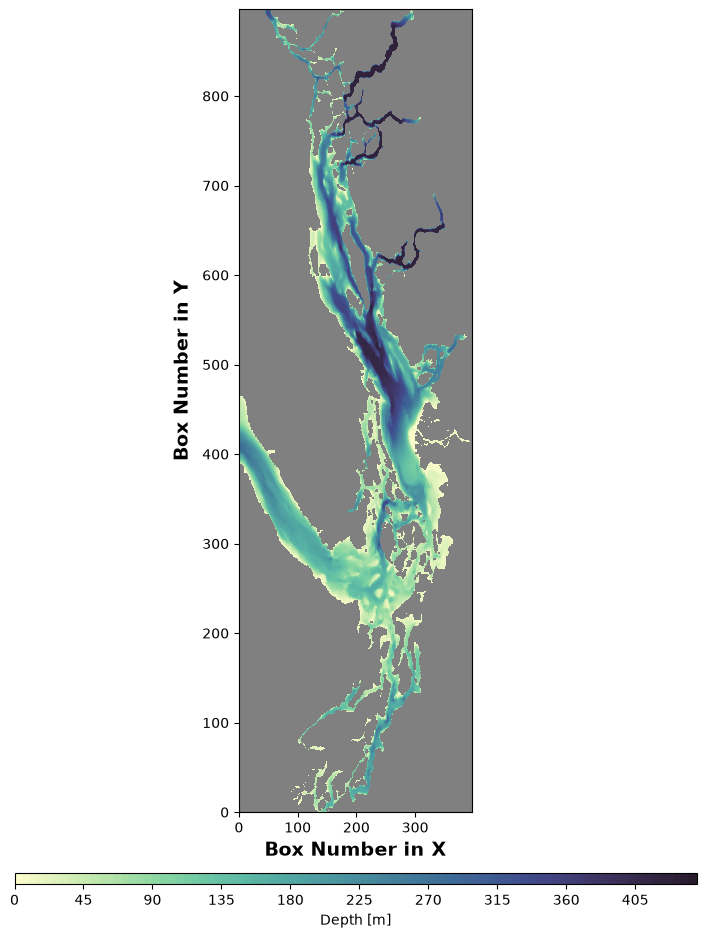

In [6]:
# Make map
blevels = list(np.arange(0,450,5))
fig, ax = plt.subplots(figsize=(8.8, 13.2))
x = np.arange(0,398)
y = np.arange(0,898)
X,Y = np.meshgrid(x,y)
#ax.add_feature(feature.GSHHSFeature('high', facecolor='#DDDDDD',edgecolor='#DDDDDD'),zorder=2)
#ax.add_feature(feature.RIVERS, edgecolor='k',zorder=5)
#ax.add_feature(feature.OCEAN,zorder=1)
im=ax.contourf(X, Y, mask.totaldepth[:,:],zorder=1,cmap=cmap,levels=blevels)
ax.contourf(X, Y, mask.umask[0,0,:,:],zorder=2,cmap='gray',levels=[-1,0])
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)


cbar = fig.colorbar(im, location='bottom',aspect=60,shrink=1,pad=0.06)

cbar.set_label('Depth [m]')
ax.text(-0.20, 0.55, 'Box Number in Y', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=14,weight="bold")
ax.text(0.5, -0.06, 'Box Number in X', va='bottom', ha='center',
        rotation='horizontal', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=14,weight="bold")

f = 1.0/np.cos(49*np.pi/180)
plt.gca().set_aspect(f)
#plt.savefig("/Users/jvalenti/Desktop/domain.pdf")

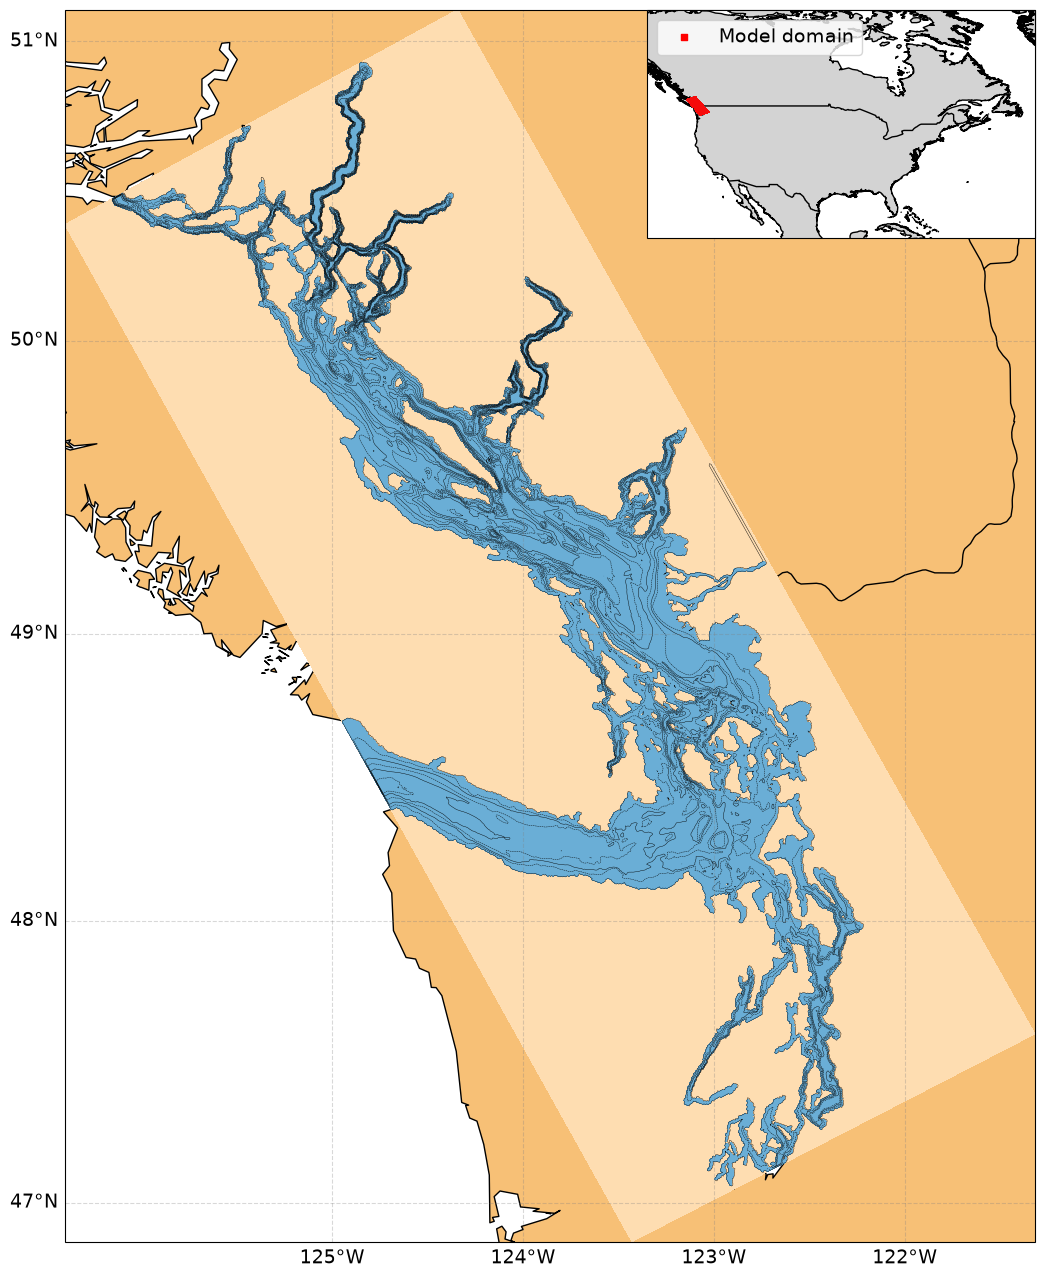

In [7]:
# Make map
fig, ax = plt.subplots(figsize=(38, 16), subplot_kw={'projection': crs.Mercator()})
ax.set_extent([np.min(coords.nav_lon),np.max(coords.nav_lon), np.min(coords.nav_lat), np.max(coords.nav_lat)], crs=crs.PlateCarree())
#ax.add_feature(feature.GSHHSFeature('high', facecolor='#DDDDDD',edgecolor='#DDDDDD'),zorder=2)
ax.add_feature(feature.GSHHSFeature('intermediate', edgecolor='k', facecolor='#F7C076'),zorder=0)
ax.add_feature(feature.RIVERS, edgecolor='k',zorder=0)
#ax.add_feature(feature.OCEAN,zorder=1)

ax.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),colors='#FEDDB1',levels=[-1,0])
ax.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),cmap='Blues',levels=[0.1,1])
ax.contour(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],transform=crs.PlateCarree(),colors='k',levels=[50,150,250,350],linewidths=0.3,linestyles='dashed')
ax.contour(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],transform=crs.PlateCarree(),colors='k',levels=[0,100,200,300,400],linewidths=0.3)
ax.tick_params(axis='both', labelsize=18)

gl = ax.gridlines(
    linestyle='--',color='gray', draw_labels=True,
    xlocs=range(-125, -121), ylocs=range(47, 52),zorder=5,alpha=0.3)
gl.xlabel_style = {'size': 14, 'color': 'black'}
gl.ylabel_style = {'size': 14, 'color': 'black'}
gl.top_labels, gl.right_labels = False, False


axins = ax.inset_axes([0.6, 0.757, 0.4, 0.3],projection=crs.PlateCarree())
axins.set_extent([-135, -50, 20, 70], crs=crs.PlateCarree())
axins.add_feature(feature.GSHHSFeature('low', edgecolor='k', facecolor='lightgray'))
axins.scatter(-4.26,55.86,transform=crs.PlateCarree(),c='red',marker='s',s=20,zorder=0,label = 'Model domain')
axins.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),colors="#F60B0B",levels=[-1,0],zorder=5)
axins.legend(loc='upper left',fontsize=14)

axins.add_feature(feature.BORDERS,zorder=3)
#gl = axins.gridlines(crs=crs.PlateCarree(), draw_labels=False, xlocs=np.linspace(-150,-50,5), ylocs=np.linspace(55,35,3),
                   #linewidth=2, color='gray', alpha=0.5, linestyle='--')
# axins.set_xticklabels('')
# axins.set_yticklabels('')

# Add the custom legend
# ax.text(-0.08, 0.55, 'Latitude', va='bottom', ha='center',
#         rotation='vertical', rotation_mode='anchor',
#         transform=ax.transAxes, fontsize=14,weight="bold")
# ax.text(0.5, -0.05, 'Longitude', va='bottom', ha='center',
#         rotation='horizontal', rotation_mode='anchor',
#         transform=ax.transAxes, fontsize=14,weight="bold")

#plt.savefig("/home/jvalenti/MOAD/map_OSM.pdf")

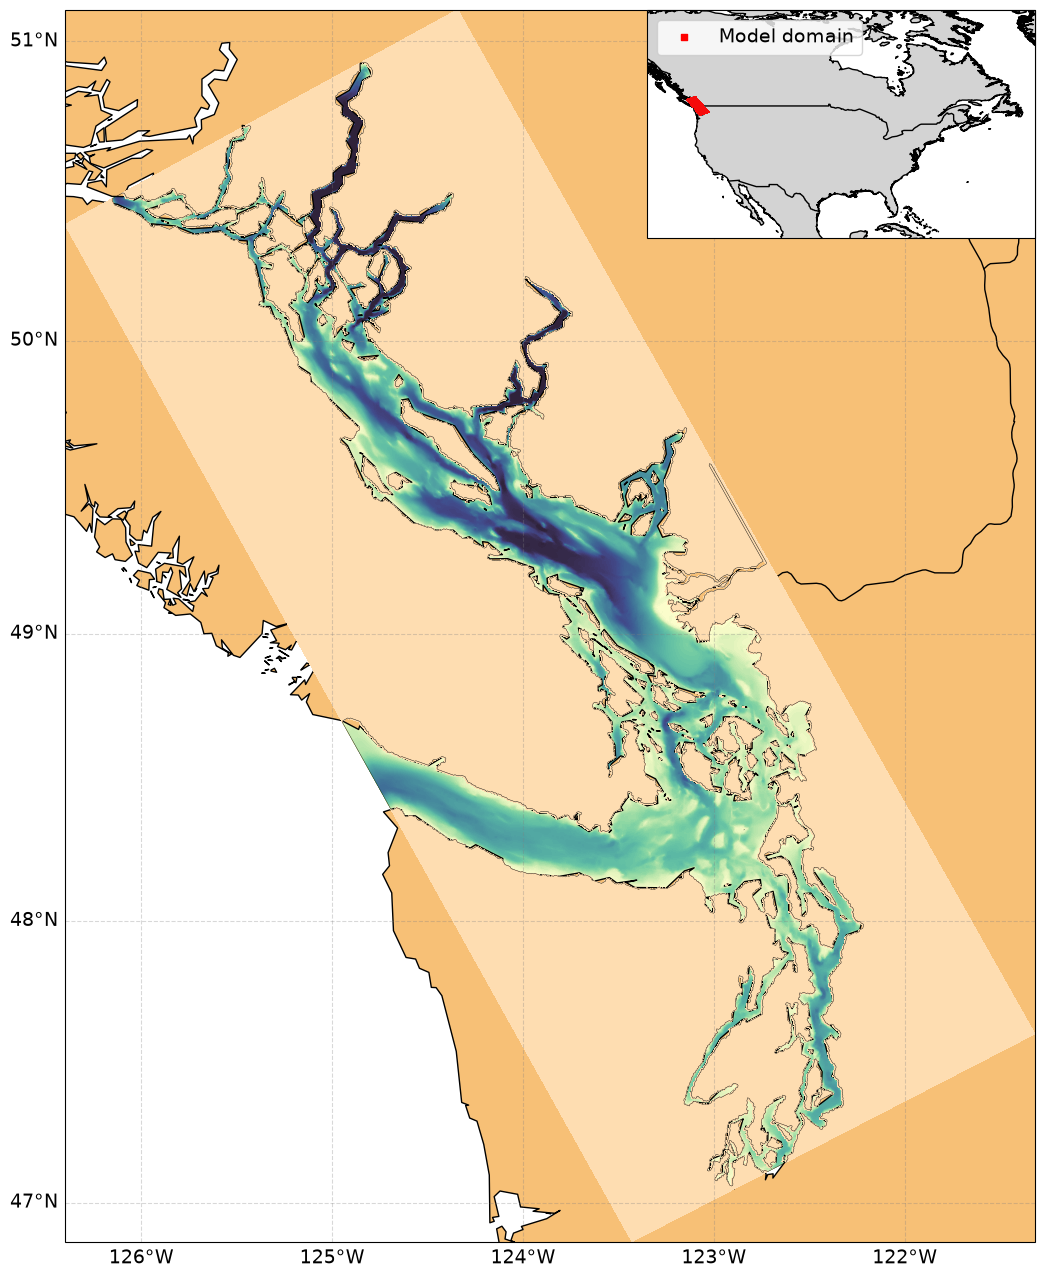

In [9]:
# Make map
fig, ax = plt.subplots(figsize=(38, 16), subplot_kw={'projection': crs.Mercator()})
ax.set_extent([np.min(coords.nav_lon),np.max(coords.nav_lon), np.min(coords.nav_lat), np.max(coords.nav_lat)], crs=crs.PlateCarree())
#ax.add_feature(feature.GSHHSFeature('high', facecolor='#DDDDDD',edgecolor='#DDDDDD'),zorder=2)
ax.add_feature(feature.GSHHSFeature('intermediate', edgecolor='k', facecolor='#F7C076'),zorder=1)
ax.add_feature(feature.RIVERS, edgecolor='k',zorder=1)
#ax.add_feature(feature.OCEAN,zorder=1)

ax.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),colors='#FEDDB1',levels=[-1,0])
#ax.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),cmap='Blues',levels=[0.1,1])
#ax.contour(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],transform=crs.PlateCarree(),colors='k',levels=[50,150,250,350],linewidths=0.3,linestyles='dashed')
#ax.contour(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],transform=crs.PlateCarree(),colors='k',levels=[0,100,200,300,400],linewidths=0.3)
ax.tick_params(axis='both', labelsize=18)

gl = ax.gridlines(
    linestyle='--',color='gray', draw_labels=True,
    xlocs=range(-126, -121), ylocs=range(47, 52),zorder=5,alpha=0.3)
gl.xlabel_style = {'size': 14, 'color': 'black'}
gl.ylabel_style = {'size': 14, 'color': 'black'}
gl.top_labels, gl.right_labels = False, False


axins = ax.inset_axes([0.6, 0.757, 0.4, 0.3],projection=crs.PlateCarree())
axins.set_extent([-135, -50, 20, 70], crs=crs.PlateCarree())
axins.add_feature(feature.GSHHSFeature('low', edgecolor='k', facecolor='lightgray'))
axins.scatter(-4.26,55.86,transform=crs.PlateCarree(),c='red',marker='s',s=20,zorder=0,label = 'Model domain')
axins.contourf(coords.nav_lon, coords.nav_lat, mask.umask[0,0,:,:],transform=crs.PlateCarree(),colors="#F60B0B",levels=[-1,0],zorder=5)
axins.legend(loc='upper left',fontsize=14)

axins.add_feature(feature.BORDERS,zorder=3)

im=ax.contourf(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],zorder=0,cmap=cmap,levels=blevels,transform=crs.PlateCarree())
ax.contour(coords.nav_lon, coords.nav_lat, mask.totaldepth[:,:],transform=crs.PlateCarree(),colors='k',levels=[0],linewidths=0.3)

#cbar = fig.colorbar(im, location='bottom',aspect=60,shrink=1,pad=0.06)